## Multiclass Classification of BBC News Articles Using LSTM

![BBC Logo](C:/Users/65814/Desktop/bbc.jpg)

### Source of Dataset
Kaggle: https://www.kaggle.com/datasets/moazeldsokyx/bbc-news

### Background

This notebook explores the application of multiclass classification on a dataset of BBC news articles. The objective is to develop a classifier that categorizes news articles into five distinct domains: sport, business, politics, technology, and entertainment. To achieve this, we trained a Long Short-Term Memory (LSTM) neural network on the BBC News dataset, leveraging its capabilities to handle sequential data and capture contextual information.

### Import Essential Libraries

In [1]:
# import essential libraries for data manipulation and data visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# import essential dependencies for constructing dense neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dropout, Dense, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import to_categorical

### Load the Dataset

In [10]:
# load the dataset
data = pd.read_csv('../data/bbc-text.csv')

# check the dimension of the dataset
numrow, numcol = data.shape
print('The dataset contains {} rows and {} columns.'.format(numrow, numcol))

# check the attributes in the dataset
attributes = data.columns
print('Attributes in the dataset:', attributes)

# view the first 5 rows of the dataset
display(data.head(n=5))

The dataset contains 2225 rows and 2 columns.
Attributes in the dataset: Index(['category', 'text'], dtype='object')


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [3]:
# summary of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [4]:
# check for duplicate records and missing value in each attributes
print('Number of duplicate records in the dataset:', data.duplicated().sum())
print('Number of missing value in each attributes:')
print(data.isna().sum())

Number of duplicate records in the dataset: 99
Number of missing value in each attributes:
category    0
text        0
dtype: int64


### Exploratory Data Analysis

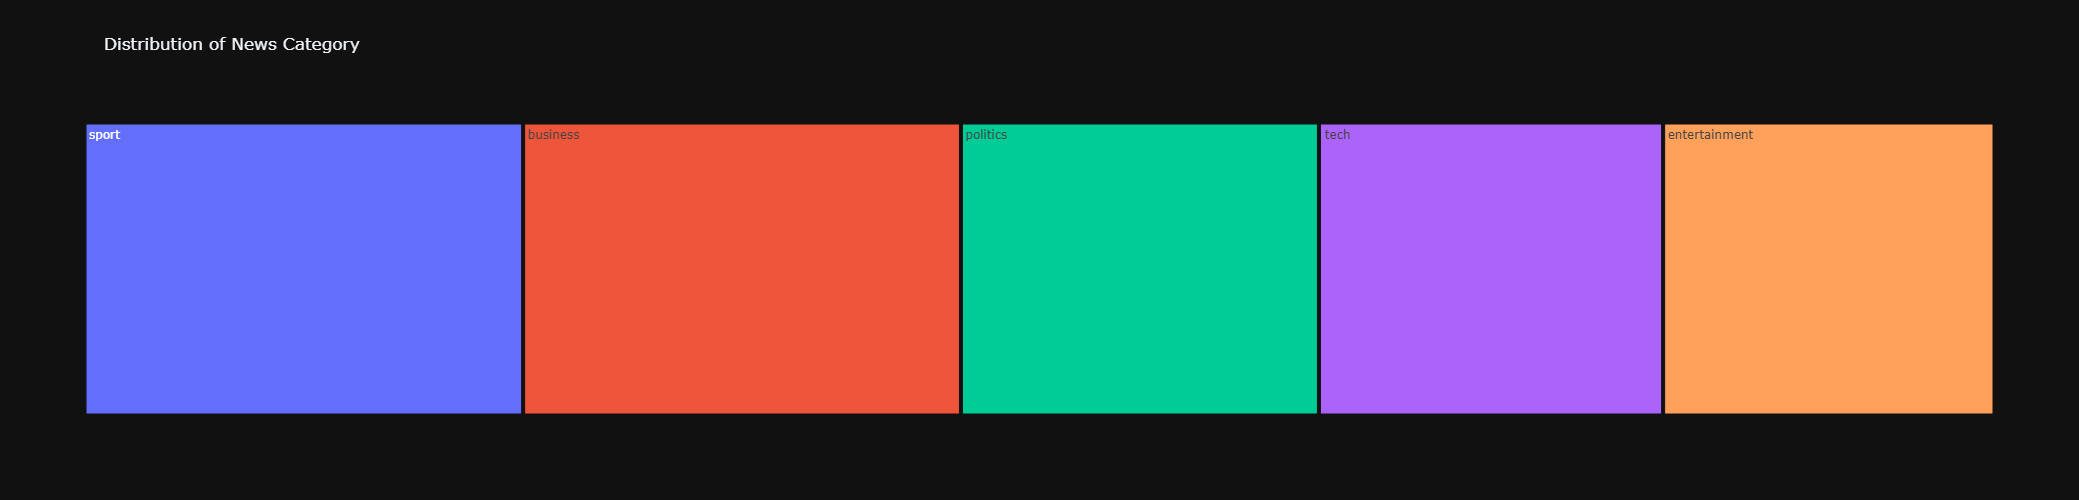

In [6]:
# distribution of the news category in the dataset
news_cat = data['category'].value_counts()
news_cat_df = pd.DataFrame(news_cat).reset_index()
news_cat_df.columns = ['Category', 'Count']

fig = px.treemap(news_cat_df, path=[news_cat_df['Category']], values='Count', 
                 width=900, height=500, 
                 template='plotly_dark', 
                 title='Distribution of News Category')
fig.show()

In [11]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize 

# function to count number of sentence in the news article
def count_sentence(text):
    count = sent_tokenize(text)
    return len(count)

# function to count number of word/token in the news article
def word_count(text):
    count = word_tokenize(text)
    return len(count)

# insert 2 additional columns for the total number of sentence and total number of words in the news article
data['sentence_number'] = data['text'].apply(lambda x: count_sentence(x))
data['word_number'] = data['text'].apply(lambda x: word_count(x))

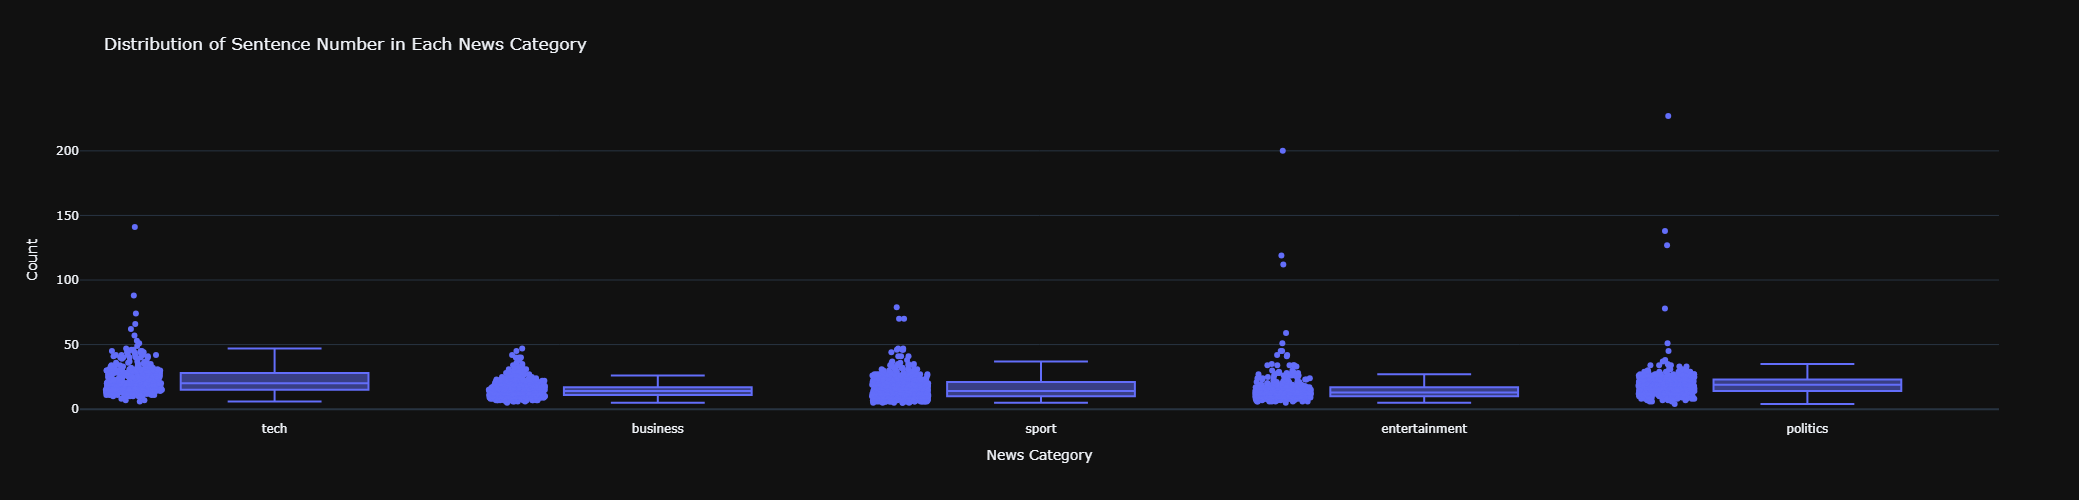

In [14]:
# distribution of sentence_number for each news category
fig = px.box(data, x='category', y='sentence_number', points='all', 
             width=900, height=500, 
             template='plotly_dark', 
             title='Distribution of Sentence Number in Each News Category')

fig.update_layout(
    xaxis = dict(
        title = 'News Category'
    ),
    yaxis = dict(
        title = 'Count'
    )
)

fig.show()

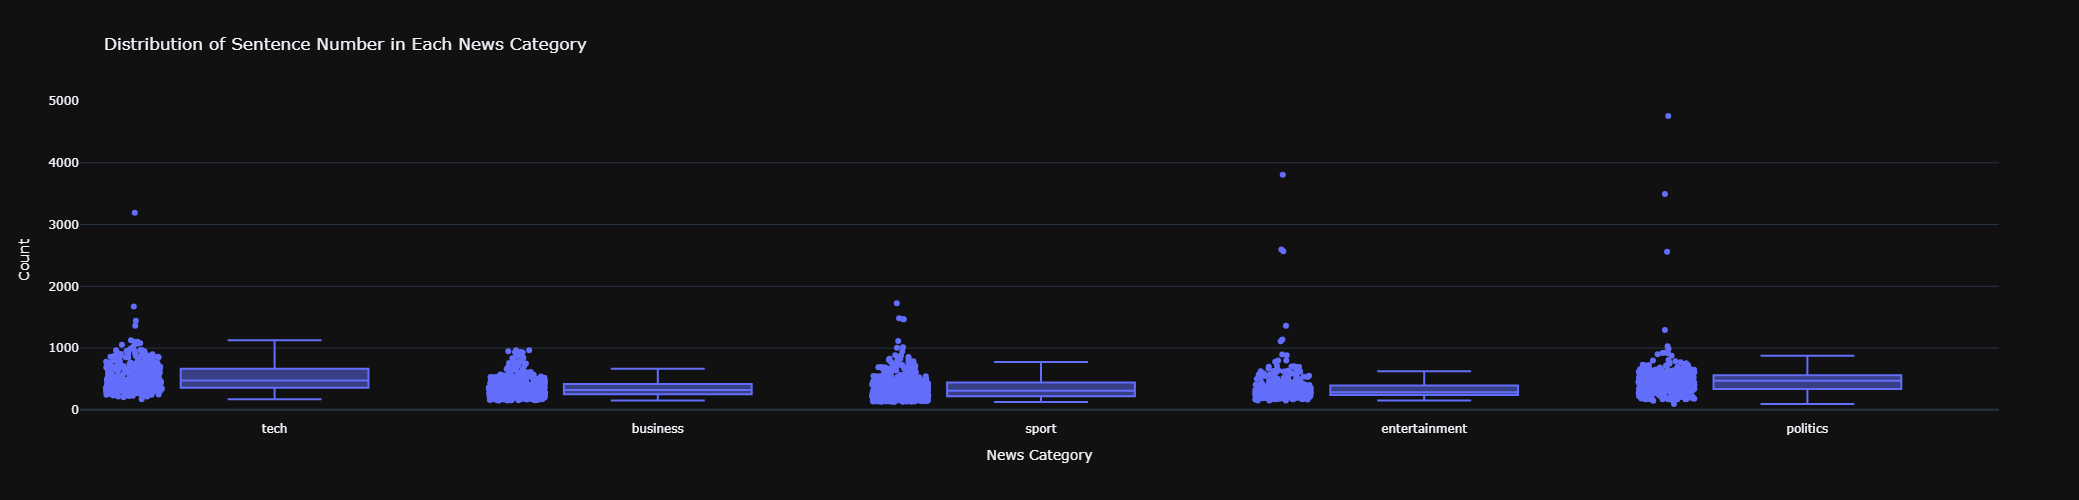

In [15]:
# distribution of word_number for each news category
fig = px.box(data, x='category', y='word_number', points='all', 
             width=900, height=500, 
             template='plotly_dark', 
             title='Distribution of Sentence Number in Each News Category')

fig.update_layout(
    xaxis = dict(
        title = 'News Category'
    ),
    yaxis = dict(
        title = 'Count'
    )
)

fig.show()

### Data Splitting

In [25]:
# data splitting
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, stratify=data['category'], shuffle=True, random_state=122)

# check the dimension of the train and test dataset
print('Dimension of the train dataset:', train.shape)
print('Dimension of the test dataset:', test.shape)

Dimension of the train dataset: (1780, 4)
Dimension of the test dataset: (445, 4)


In [26]:
# segregate the train and test dataset into feature matrix and target vector
Xtrain = train['text']
ytrain = train['category']

Xtest = test['text']
ytest = test['category']

In [65]:
# initialize a tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token = '<OOV>')

# create the vocabulary using training data
tokenizer.fit_on_texts(Xtrain)

In [85]:
# convert the train and test data into sequence
timesteps = 100

train_sequence = tokenizer.texts_to_sequences(Xtrain)
padded_train_sequence = pad_sequences(train_sequence, maxlen=timesteps, padding='post')

test_sequence = tokenizer.texts_to_sequences(Xtest)
padded_test_sequence = pad_sequences(test_sequence, maxlen=timesteps, padding='post')

In [86]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
ytrain_indices = encoder.fit_transform(ytrain)
ytest_indices = encoder.transform(ytest)

In [87]:
num_classes = ytrain.nunique()
ytrain_encoded = to_categorical(ytrain_indices, num_classes=num_classes)
ytest_encoded = to_categorical(ytest_indices, num_classes=num_classes)

### Neural Network Construction

In [105]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    Dropout(0.3),
    LSTM(units=50, return_sequences=True),
    Dropout(0.4),
    LSTM(units=50, return_sequences=False),
    Dropout(0.5),
    Dense(units=5, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [106]:
history = model.fit(padded_train_sequence, ytrain_encoded, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.2608 - loss: 1.5988 - val_accuracy: 0.3258 - val_loss: 1.5034
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.4415 - loss: 1.2324 - val_accuracy: 0.6461 - val_loss: 0.8910
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7231 - loss: 0.7319 - val_accuracy: 0.8006 - val_loss: 0.6722
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.9183 - loss: 0.3285 - val_accuracy: 0.8287 - val_loss: 0.5882
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9527 - loss: 0.1849 - val_accuracy: 0.8034 - val_loss: 0.6602
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9585 - loss: 0.1658 - val_accuracy: 0.8539 - val_loss: 0.5571
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9845 - loss: 0.0626 - val_accuracy: 0.8483 - val_loss: 0.5618
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.9944 - loss: 0.0403 - val_accuracy: 0.8483 - v

,accuracy,loss,val_accuracy,val_loss
0,0.294944,1.564730,0.325843,1.503401
1,0.478230,1.151899,0.646067,0.891032
2,0.777388,0.630149,0.800562,0.672217
3,0.942416,0.263840,0.828652,0.588215
4,0.949438,0.200324,0.803371,0.660239
5,0.970506,0.137776,0.853933,0.557085
6,0.986657,0.060381,0.848315,0.561762
7,0.993680,0.043999,0.848315,0.615672
8,0.997191,0.029529,0.853933,0.642851
9,0.997893,0.024188,0.828652,0.739617


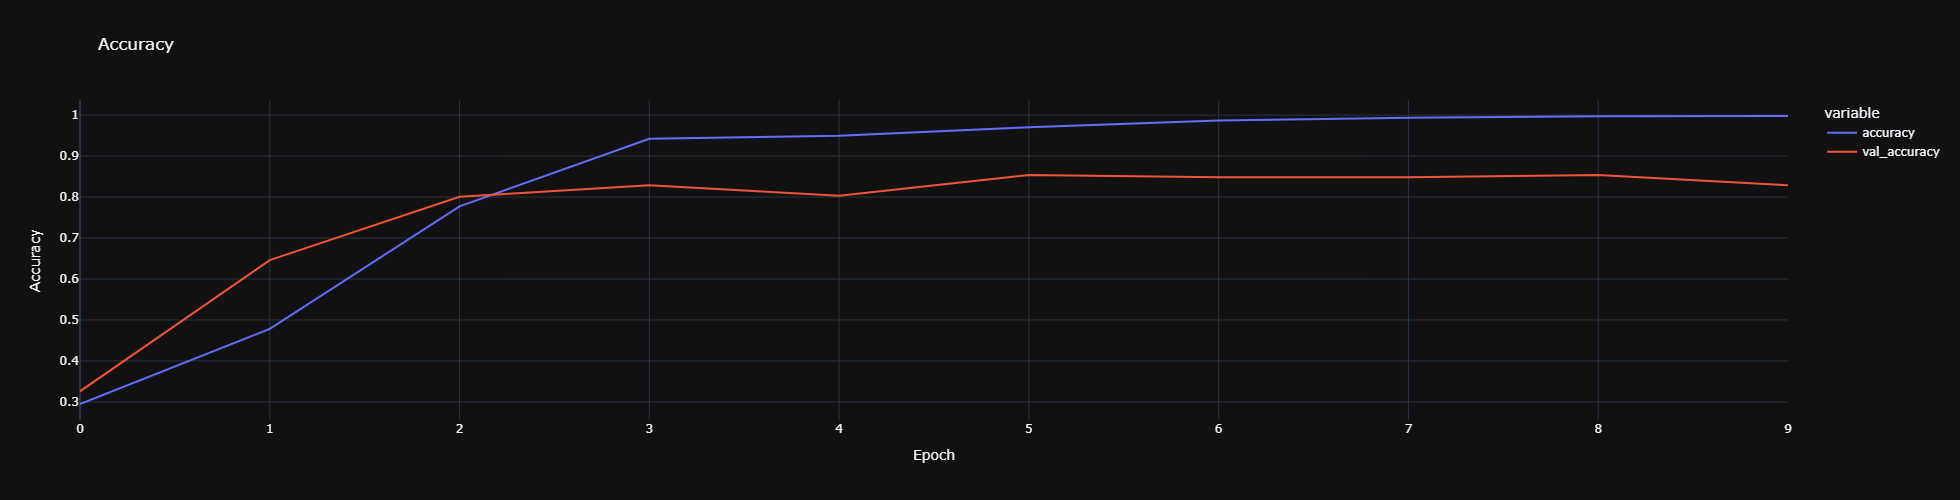

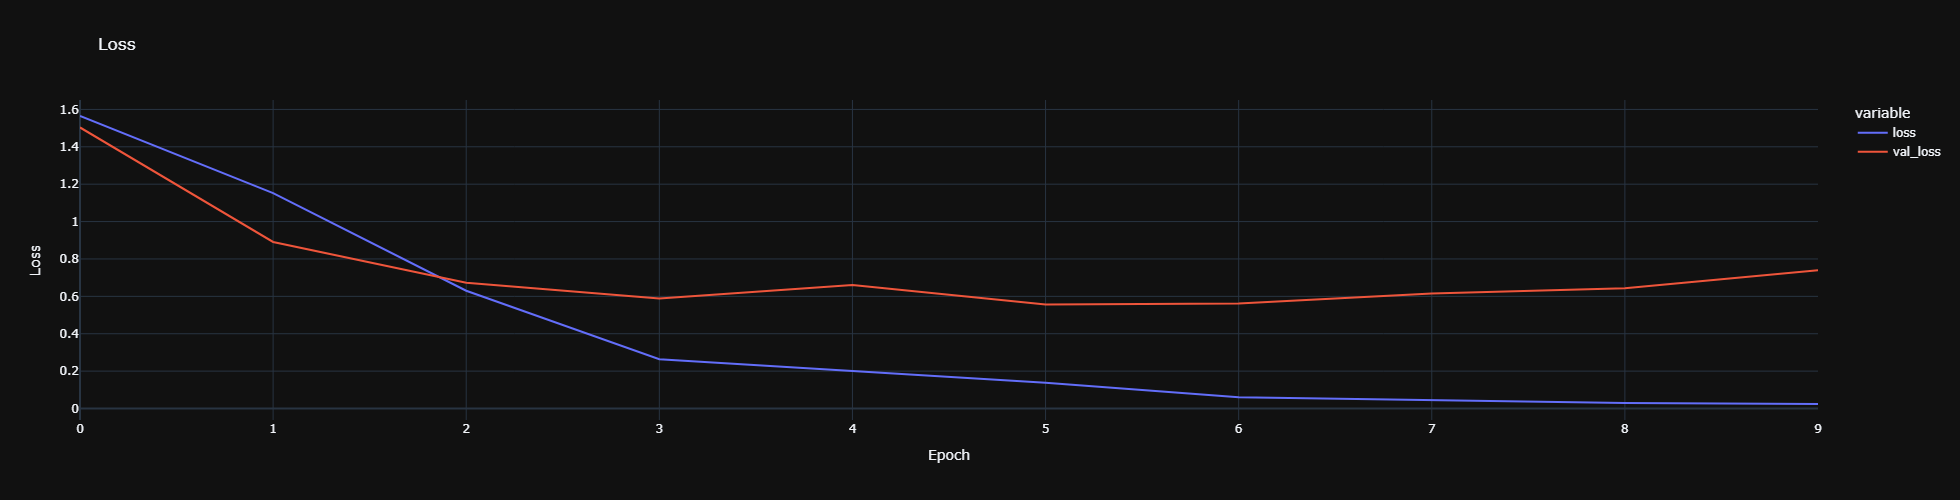

In [107]:
# visualize the training progress
# plot the graph of loss and accuracy epoch-by-epoch

# create a dataframe for the training history
history_df = pd.DataFrame(history.history)
display(history_df)

# subset the accuracy and loss dataframe from the history_df
accuracy_df = history_df[['accuracy','val_accuracy']]
loss_df = history_df[['loss','val_loss']]

# visualize the accuracy during training progress
fig = px.line(accuracy_df, width=800, height=500, template='plotly_dark', title='Accuracy')

fig.update_layout(
    xaxis = dict(
        title = 'Epoch'
    ),
    yaxis = dict(
        title = 'Accuracy'
    )
)

fig.show()

# visualize the loss during training progress
fig = px.line(loss_df, width = 800, height=500, template='plotly_dark', title='Loss')

fig.update_layout(
    xaxis = dict(
        title = 'Epoch'
    ),
    yaxis = dict(
        title = 'Loss'
    )
)

fig.show()

### Model Evaluation

In [108]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix

def model_performance(X, y, model):
    # predict the classes for the test set
    ypred = model.predict(X)
    ypred_classes = ypred.argmax(axis=-1)
    
    accuracy = round(accuracy_score(y, ypred_classes), 3)
    precision = round(precision_score(y, ypred_classes, average='weighted'), 3)
    recall = round(recall_score(y, ypred_classes, average='weighted'), 3)
    f1 = round(f1_score(y, ypred_classes, average='weighted'), 3)
    
    print('Key Peformance Metrics:\n')
    print('Accuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)

    cm = confusion_matrix(y, ypred_classes)
    sns.heatmap(cm, annot=True, fmt='.4g', cmap='BuPu', cbar=False)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Key Peformance Metrics:

Accuracy: 0.847
Precision: 0.855
Recall: 0.847
F1 Score: 0.846


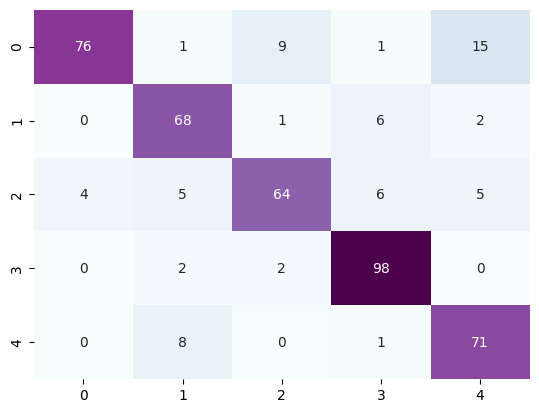

In [109]:
model_performance(padded_test_sequence, ytest_indices, model)